# Dimensionality Reduction

## PCA

* In Principal Component Analysis (PCA) we seek to take a data set like the one shown below and apply a transform to the data such that the new axes are **aligned with the maximal variance** of the data.
* This is basically just the same as doing regression by minimizing the square of the perpendicular distances to the new axes. Note that we haven't made any changes to the data, we have just defined new axes.
* The **first axis**, or principal component, is the direction of maximal variance. The **second principal component** is orthogonal to the first component and maximizes the residual variance

In [24]:
#Example call from 7.3.2
import numpy as np
from sklearn.decomposition import PCA

X = np.random.normal(size=(100,3)) # 100 points in 3D
R = np.random.random((3,10)) # projection matrix
X = np.dot(X,R) # X is now 10-dim, with 3 intrinsic dims

pca = PCA(n_components=4) 
pca.fit(X) # calcola media dei dati, individua autovettori e autovalori dalla matrice di covarianza

projections = pca.transform(X) # compute the subspace projection of X, 4 coordinates for 100 data
mean = pca.mean_ # computed during pca.fit()
eigenvectors = pca.components_ # 4x10 matrix of components, each row is a versor in a 10-dim space

# Reconstruction of object1
# Xreconstruct[0] = mean + eigenvectors*eigenvalues[0]

print(projections.shape)
print(eigenvectors.shape)

(100, 4)
(4, 10)


* Let's see an example and plot the amount of information carried by each component of the decomposition: **cumulative explained variance ratio**
* si esatre con pca.explained_variance_ratio[]

In [26]:
# Example from Andy Connolly
# See Ivezic, Figure 7.4

from sklearn.decomposition import PCA
#from sklearn.decomposition import RandomizedPCA

from astroML.datasets import sdss_corrected_spectra
from astroML.utils import pickle_results

data = sdss_corrected_spectra.fetch_sdss_corrected_spectra()
spectra = sdss_corrected_spectra.reconstruct_spectra(data)
wavelengths = sdss_corrected_spectra.compute_wavelengths(data)
print('Number of spectra: ' + str(len(spectra)))
print('Number of wavelength bins: ' + str(len(wavelengths)))

#----------------------------------------------------------------------
# Compute PCA
np.random.seed(500)
nrows = 2000 # We'll just look at 2000 random spectra
n_components = 5 # Do the fit with 5 components, which is the mean plus 4
ind = np.random.randint(spectra.shape[0], size=nrows)

spec_mean = spectra[ind].mean(0) # Compute the mean spectrum, which is the first component
# spec_mean = spectra[:50].mean(0)

# use Randomized PCA for speed
# pca = RandomizedPCA(n_components - 1)
pca = PCA(n_components - 1, svd_solver='randomized')
pca.fit(spectra[ind])
pca_comp = np.vstack([spec_mean, pca.components_]) # Add the mean to the components
evals = pca.explained_variance_ratio_ 
print('Expained fractional variance of data encapsulated in the eigenvalues: ' + str(evals))

Number of spectra: 4000
Number of wavelength bins: 1000
Expained fractional variance of data encapsulated in the eigenvalues: [0.8893161  0.06058302 0.02481435 0.01012149]


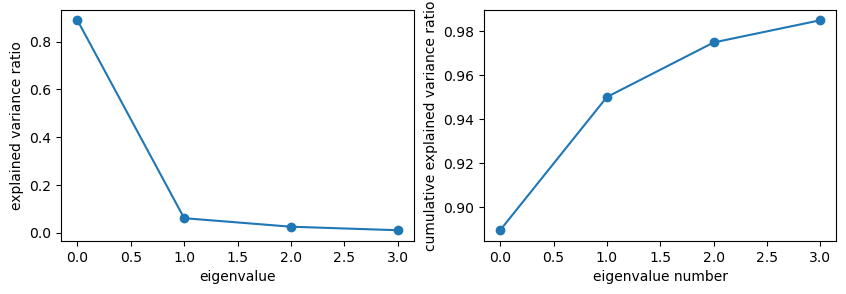

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

# Plot the results
fig = plt.figure(figsize=(10, 3))

ax = fig.add_subplot(121)

ax.plot(np.arange(n_components-1), evals)
ax.scatter(np.arange(n_components-1), evals)

ax.set_xlabel("eigenvalue")
ax.set_ylabel("explained variance ratio")

ax = fig.add_subplot(122)

ax.plot(np.arange(n_components-1), evals.cumsum())
ax.scatter(np.arange(n_components-1), evals.cumsum())

ax.set_xlabel("eigenvalue number")
ax.set_ylabel("cumulative explained variance ratio")

plt.show()

**This is why PCA enables dimensionality reduction**. We can use samples of measured data to train a data-driven basis that better explains it.

* How many components would we need to explain 99.5% of the variance?

In [27]:
for num_feats in np.arange(1,20, dtype = int):
    pca = PCA(n_components=num_feats)
    pca.fit(spectra[ind])
    if (sum(pca.explained_variance_ratio_)>0.995):
        break
print("{:d} features are needed to explain 99.5% of the variance".format(num_feats))

8 features are needed to explain 99.5% of the variance


Alternatively impose a **number of dimension between 0 and 1**. It will be seen as the **percentege of variance to be captured**.

In [ ]:
pca995 = PCA(n_components=0.995)
pca995.fit(spectra[ind])
print("{:d} features are needed to explain 99.5% of the variance".format(pca995.n_components_))

8 features are needed to explain 99.5% of the variance


### Interpreting PCA

* The output eigenvectors are **ordered** by their associated eigenvalues
* The **eigenvalues** reflect the variance within each eigenvector, it measures exactly how much of the dataset's **total variance is stretched along its corresponding eigenvector** (Principal Component).
* The sum of the eigenvalues is total variance of the system.
* The projection of each spectrum onto the first few eigenspectra is a compression of the data

For example, we started with 4000 x 1000 floating point numbers. If we can explain nearly all of the variance with 8 eigenvectors, then we have reduced the problem to 4000 x 8 (the eigenspectra) + 8 x 1000 (the component weights) floating point numbers!

* How many components to keep? Cross validate with differnt numbers of components or use **scree plot** (which is a representation of eigenspectra, component number vs eigenvalue)
* PCA to reconstruct missing data. PCA learns a data-driven basis that is a linear combination of features that best explain the observed data. So it uses correlations across the features, which in this case are wavelengths. Those correlated features can be used to interpolate across or reconstruct missing data.

**Warning** A note of caution about the techniques you saw in the last lecture: PCA, NMF, and ICA are all linear methods.\
Astronomers will often try to derive physical insight from PCA eigenspectra or eigentimeseries, but there is **no physical reason for the data to be linearly and orthogonally separable**.\
Moreover, physical components are (generally) positive definite. So, PCA is great for dimensional reduction, but for doing physics there are generally better choices -> **non-linear** algorithm in sklearn.manifold

# The HR diagram

### Data visualization

In [2]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")

import pandas as pd
df_stars = pd.read_csv("stars.csv")

df_stars


,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

le = LabelEncoder() #convert strings into integers
df_stars['Star type'] = le.fit_transform(df_stars['Star type'])
labels = le.inverse_transform(df_stars['Star type'])
class_names = le.classes_
print(class_names)


['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']


In [4]:
ce = LabelEncoder()
df_stars['Star color'] = ce.fit_transform(df_stars['Star color'])
colors = ce.inverse_transform(df_stars['Star color'])
color_names = ce.classes_
print(color_names)

['Blue' 'Blue ' 'Blue White' 'Blue white' 'Blue white ' 'Blue-White'
 'Blue-white' 'Orange' 'Orange-Red' 'Pale yellow orange' 'Red' 'White'
 'White-Yellow' 'Whitish' 'Yellowish' 'Yellowish White' 'white'
 'yellow-white' 'yellowish']


In [5]:
sc = LabelEncoder()
df_stars['Spectral Class'] = sc.fit_transform(df_stars['Spectral Class'])
spectral_classes = sc.inverse_transform(df_stars['Spectral Class'])
spectral_class_names = sc.classes_
print(spectral_class_names)

['A' 'B' 'F' 'G' 'K' 'M' 'O']


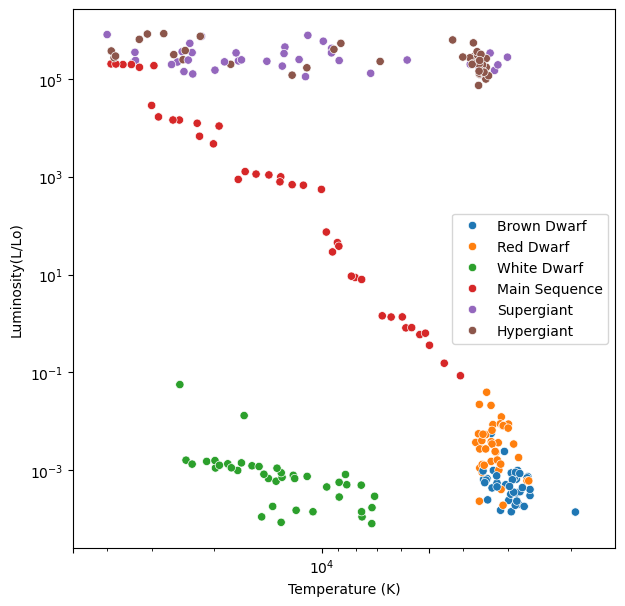

In [6]:
import seaborn as sns
fig = plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_stars, x='Temperature (K)', y='Luminosity(L/Lo)', hue=labels, palette='tab10')
plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3)
plt.show()

### PCA dimensionality reduction

Primo tentativo con dati non standardizzati e solver=randomizer \
Provato sia 2 che 4 componenti, stesso contenuto di info presente nella prima componente 99.7%

In [7]:
#labels into numbers per plot
le = LabelEncoder()
encoded_types = le.fit_transform(df_stars['Star type'])
class_names = le.classes_

#preparo input per PCA
colonne_da_escludere = ['Star type', 'Star color', 'Spectral Class']
X = df_stars.drop(columns=colonne_da_escludere).select_dtypes(include='number')
pca = PCA(n_components=2, svd_solver='randomized') #PCA guarda il tuo dataset, studia la forma della nuvola di punti, calcola il centro esatto, le varianze e trova le direzioni migliori (gli autovettori) per schiacciare i dati.
transf_data = pca.fit_transform(X) #applica per davvero la reduction e proietta i dati sugli autovettori calcolati, l'asse principale è quello con autovalore maggiore.

#attributi con _ sono valori imparati dal modello durante il fit
eigenvectors = pca.components_                      
variance = pca.explained_variance_
variance_percent = pca.explained_variance_ratio_ 
print('Expained fractional variance of data encapsulated in the eigenvalues: ' + str(variance_percent))

pca995 = PCA(n_components=0.995)
pca995.fit(X)
print("{:d} features are needed to explain 99.5% of the variance".format(pca995.n_components_))


Expained fractional variance of data encapsulated in the eigenvalues: [0.99760631 0.0023879 ]
1 features are needed to explain 99.5% of the variance


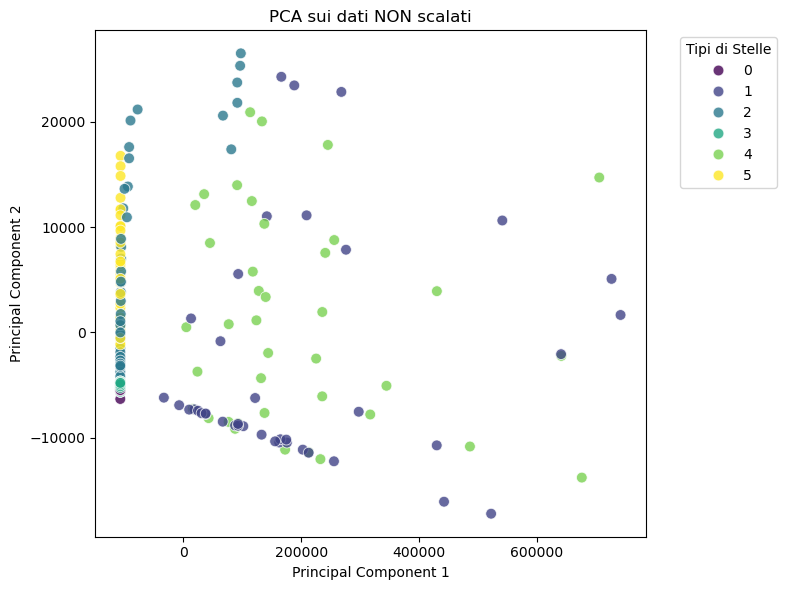

In [ ]:
plt.figure(figsize=(8, 6))

# sns.scatterplot fa il lavoro di plt.scatter + plt.legend automaticamente
sns.scatterplot(x=transf_data[:, 0], y=transf_data[:, 1], hue=df_stars['Star type'],palette='viridis',alpha=0.8,s=60)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA sui dati NON scalati')
plt.legend(title="Tipi di Stelle", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Primo tentativo con dati non standardizzati e solver=randomizer \
Provato sia 2 che 4 componenti, stesso contenuto di info presente nella prima componente 99.7%

In [9]:
# apply standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) 

pca_scaled = PCA(n_components=2, svd_solver='randomized')
transf_scaled_data = pca_scaled.fit_transform(X_scaled)

#attributi con _ sono valori imparati dal modello durante il fit
eigenvectors = pca_scaled.components_                      
variance = pca_scaled.explained_variance_
variance_percent = pca_scaled.explained_variance_ratio_ 
print('Expained fractional variance of data encapsulated in the eigenvalues: ' + str(variance_percent))

pca995 = PCA(n_components=0.995)
pca995.fit(X_scaled)
print("{:d} features are needed to explain 99.5% of the variance".format(pca995.n_components_))

Expained fractional variance of data encapsulated in the eigenvalues: [0.60357391 0.23500784]
4 features are needed to explain 99.5% of the variance


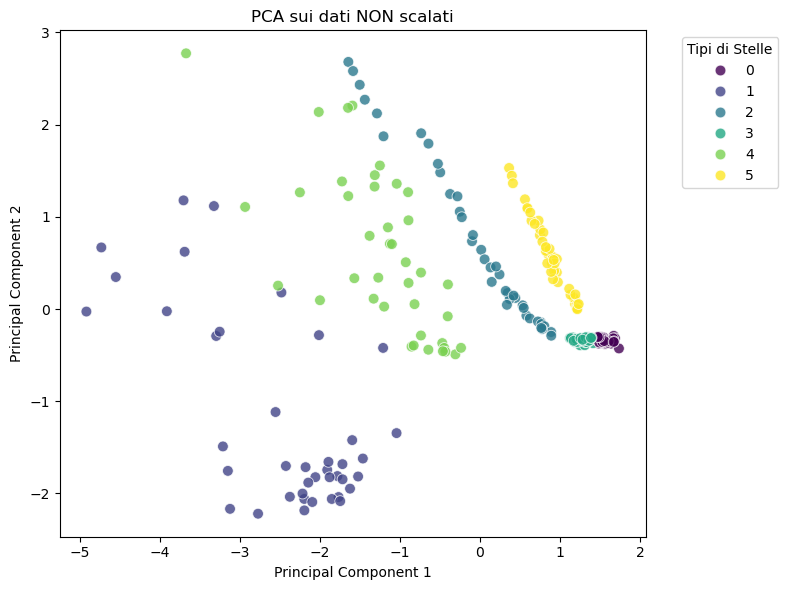

In [ ]:
plt.figure(figsize=(8, 6))

# sns.scatterplot fa il lavoro di plt.scatter + plt.legend automaticamente
sns.scatterplot(x=transf_scaled_data[:, 0], y=transf_scaled_data[:, 1], hue=df_stars['Star type'],palette='viridis',alpha=0.8,s=60)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA sui dati scalati')

plt.legend(title="Tipi di Stelle", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [50]:
variance_percent = pca_scaled.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_percent)
print(variance_percent, cumulative_variance)

[0.60357391 0.23500784 0.09329645 0.0681218 ] [0.60357391 0.83858175 0.9318782  1.        ]


## NonLinear dimensionality reduction

List of possible non linear dim reduction alogorithms:
* t-distributed Stochastic Neighbor Embedding (t-SNE)
* locally linear embedding (LLE)
* isometric mapping (IsoMap)

### LLE and IsoMap

* LLE works on preserving the local geometry of each point, computing the projection of neighbours (through wights) in the tangent space of each point (W).\
 Build the embedded space keeping the information in W  to preserve the local geometry

* IsoMap seeks to find a lower dimensional embedding of the data marix that maintains the geodesic distances between all points. Rather than using Euclidean distances between points, IsoMap actually approximates geodesic curves that lie in the embedded manifold, then computes the distances between each point in the data set along these geodesics.

### t-SNE

* Measure similiraty in the original space in terms of probability, using a multivariate gaussian at each point, measure all neighbourghs similarity. Similarity matrix is a measure of the local structure.
* In a lower dim space, measure similarity using t-student instead of gaussian, compute again a similarity matrix.
* Find the best trasformation from high to low dim space by minimizing differences between the two matrix (Kullback-Liebler Divergence)


In [44]:
# t-SNE
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2,learning_rate=10)

X_tsne = tsne.fit_transform(X)
X_scaled_tsne = tsne.fit_transform(X_scaled)

fit_quality = tsne.kl_divergence_       # measure of the amount of loss information
print(fit_quality)

0.12319760024547577


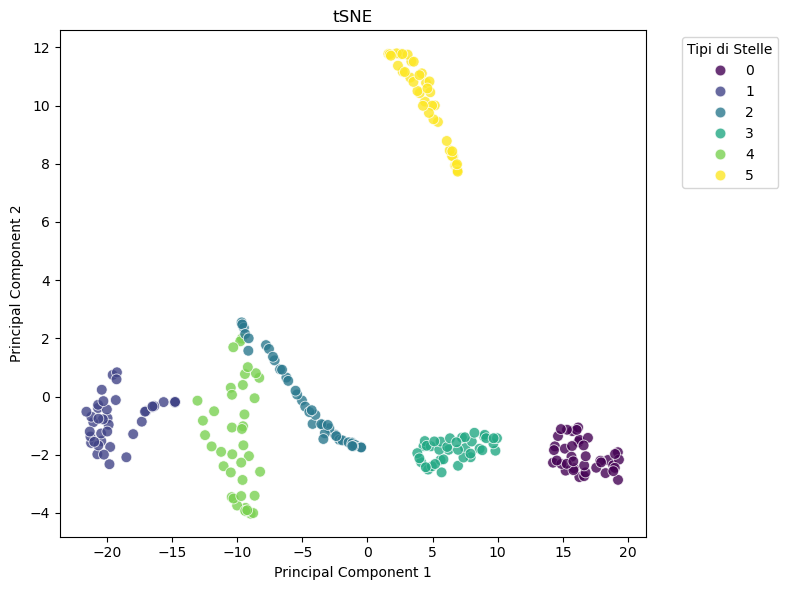

In [ ]:
plt.figure(figsize=(8, 6))

# sns.scatterplot fa il lavoro di plt.scatter + plt.legend automaticamente
sns.scatterplot(x=X_scaled_tsne[:, 0], y=X_scaled_tsne[:, 1], hue=df_stars['Star type'],palette='viridis',alpha=0.8,s=60)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('tSNE')

# Spostiamo la legenda fuori dal grafico per non coprire i punti
plt.legend(title="Tipi di Stelle", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()